# DeePyMoD Modular PD Discovery Demo

This notebook demonstrates the new **module-aware** PD structure discovery pipeline:
- Multi-state network (R + latent states)
- Module-scoped candidate library
- Multi-equation pruning + ranking

It mirrors the flow of `demo/01_demo_report.ipynb`, but focuses on **module combinations**.

In [1]:
from src.data.simulate_pkpd import self_check_models
report = self_check_models(seed=42, n_subjects=2, verbose=True)
report

[OK] DIRECT_LINEAR
[OK] DIRECT_EMAX
[OK] DIRECT_SIGEMAX
[OK] BIOPHASE_EMAX
[OK] BIOPHASE_SIGEMAX
[OK] IDR_BASE
[OK] IDR_INHIB_KIN_SIG
[OK] IDR_STIM_KIN_SIG
[OK] IDR_INHIB_KOUT_SIG
[OK] IDR_STIM_KOUT_SIG
[OK] TMDD_BASE
[OK] TRANSDUCTION_DELAY
[OK] FEEDBACK_REGULATION
[OK] CIRCADIAN_REGULATION
[OK] TGI_BASIC
[OK] DISEASE_PROGRESSION
[OK] TOLERANCE_ADAPTATION
[OK] DRUG_INTERACTION
[OK] PRECURSOR_POOL
[OK] ANTIBODY_PKPD


{'ok': ['DIRECT_LINEAR',
  'DIRECT_EMAX',
  'DIRECT_SIGEMAX',
  'BIOPHASE_EMAX',
  'BIOPHASE_SIGEMAX',
  'IDR_BASE',
  'IDR_INHIB_KIN_SIG',
  'IDR_STIM_KIN_SIG',
  'IDR_INHIB_KOUT_SIG',
  'IDR_STIM_KOUT_SIG',
  'TMDD_BASE',
  'TRANSDUCTION_DELAY',
  'FEEDBACK_REGULATION',
  'CIRCADIAN_REGULATION',
  'TGI_BASIC',
  'DISEASE_PROGRESSION',
  'TOLERANCE_ADAPTATION',
  'DRUG_INTERACTION',
  'PRECURSOR_POOL',
  'ANTIBODY_PKPD'],
 'failed': {}}

In [2]:
import os
from src.report.init_report_run import init_and_create_skeleton

manifest, report_md = init_and_create_skeleton(
    project_root=os.path.abspath(".."),
    run_name=None,
)

print("Run dir:", manifest["paths"]["run_dir"])
print("Report :", report_md)

Run dir: D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643
Report : D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\report.md


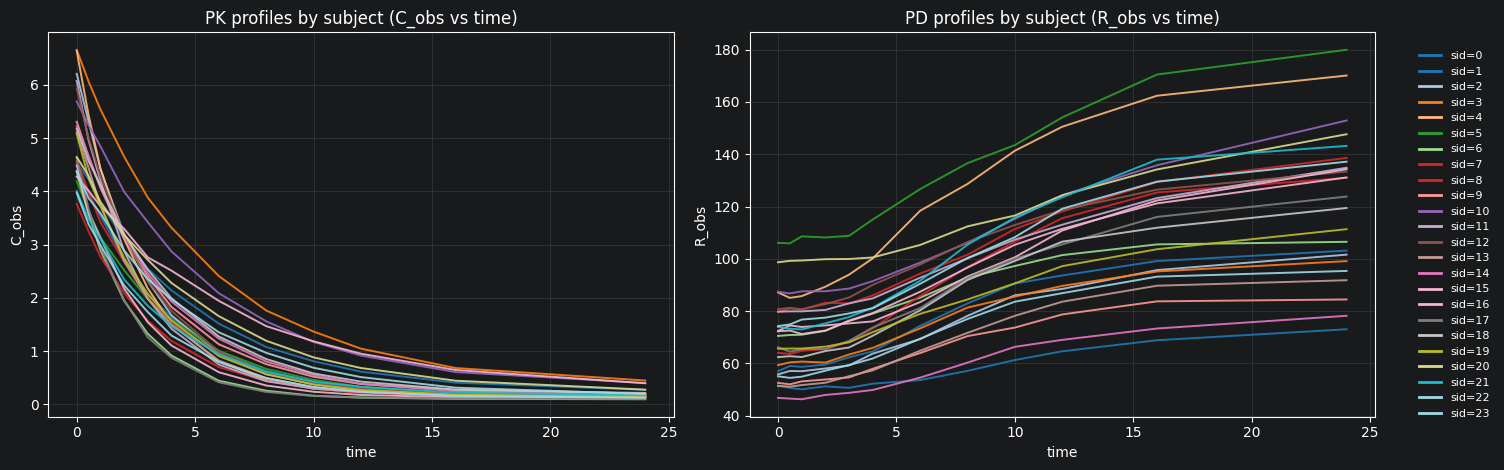

In [3]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data.simulate_pkpd import generate_population_data
from src.configs import pkpd_registry

if "manifest" not in globals():
    raise RuntimeError("请先执行 Step 0")

pkpd_registry.t_dense = np.linspace(0, 240, 241)   # 0-240
pkpd_registry.t_obs = np.array([0,1,2,3,5,7,10,14,21,28,35,42], float)

pkpd_registry.tv_pk["ka"] = 0.0
pkpd_registry.tv_pk["D"]  = 100.0

ant = pkpd_registry.MODEL_REGISTRY["ANTIBODY_PKPD"]["tv_pd"]
ant["CLp"] = 0.02     # 原来 0.2 -> 降 10 倍
ant["Q"]   = 0.02     # 原来 0.3 -> 降 10+ 倍
ant["Kon"] = 0.005    # 原来 0.05 -> 降 10 倍
ant["keDR"]= 0.002    # 原来 0.02 -> 降 10 倍
ant["V2"]  = 20.0     # 增大 central volume
ant["Vt"]  = 30.0     # 增大 tissue volume

model_name = "ANTIBODY_PKPD"
seed = 42
n_subjects = 24
extra_pk_iiv_sigma = 0.10

run_dir = manifest["paths"]["run_dir"]
data_dir = os.path.join(run_dir, "data")
os.makedirs(data_dir, exist_ok=True)

pop_data, subject_params, cfg, pk_scale_by_sid = generate_population_data(
    model_name=model_name,
    seed=seed,
    n_subjects=n_subjects,
    extra_pk_iiv_sigma=extra_pk_iiv_sigma,
    return_pk_scale=True,
)

df = pd.DataFrame(pop_data, columns=["sid", "time", "C_obs", "R_obs"])
df["sid"] = df["sid"].astype(int)

csv_path = os.path.join(data_dir, "pkpd_long.csv")
cfg_path = os.path.join(data_dir, "sim_config.json")
subj_path = os.path.join(data_dir, "subject_params.json")
fig_pkpd_lines = os.path.join(data_dir, "pkpd_lines_by_subject.png")

df.to_csv(csv_path, index=False)

def _jsonable(x):
    if isinstance(x, dict):
        return {k: _jsonable(v) for k, v in x.items()}
    if isinstance(x, list):
        return [_jsonable(v) for v in x]
    if isinstance(x, tuple):
        return tuple(_jsonable(v) for v in x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    return x

meta = {
    "data_source": "simulated_from_src",
    "generator": "src.data.simulate_pkpd.generate_population_data",
    "model_name": model_name,
    "seed": seed,
    "n_subjects": n_subjects,
    "extra_pk_iiv_sigma": float(extra_pk_iiv_sigma),
    "cfg": _jsonable(cfg),
    "run_dir": run_dir,
}

with open(cfg_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

with open(subj_path, "w", encoding="utf-8") as f:
    json.dump(_jsonable(subject_params), f, ensure_ascii=False, indent=2)

# 受试者分色折线图
df_plot = df.sort_values(["sid", "time"]).copy()
sids = sorted(df_plot["sid"].unique())
cmap = plt.get_cmap("tab20", len(sids))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)

for i, sid in enumerate(sids):
    g = df_plot[df_plot["sid"] == sid]
    axes[0].plot(g["time"], g["C_obs"], color=cmap(i), lw=1.4, alpha=0.9)
axes[0].set_title("PK profiles by subject (C_obs vs time)")
axes[0].set_xlabel("time"); axes[0].set_ylabel("C_obs"); axes[0].grid(alpha=0.2)

for i, sid in enumerate(sids):
    g = df_plot[df_plot["sid"] == sid]
    axes[1].plot(g["time"], g["R_obs"], color=cmap(i), lw=1.4, alpha=0.9)
axes[1].set_title("PD profiles by subject (R_obs vs time)")
axes[1].set_xlabel("time"); axes[1].set_ylabel("R_obs"); axes[1].grid(alpha=0.2)

handles = [plt.Line2D([0], [0], color=cmap(i), lw=2) for i in range(len(sids))]
labels = [f"sid={sid}" for sid in sids]
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(fig_pkpd_lines, dpi=160, bbox_inches="tight")

In [4]:
import os
from src.report.summary_plot import (
    load_pkpd_csv, save_snapshot_and_summary, plot_pkpd_scatter
)

run_dir = manifest["paths"]["run_dir"]
tables_dir = os.path.join(run_dir, "tables")
fig_dir = os.path.join(run_dir, "figures")

df_long = load_pkpd_csv(os.path.join(run_dir, "data", "pkpd_long.csv"))
snap_csv, summary_json, summary = save_snapshot_and_summary(df_long, tables_dir)
fig_path = plot_pkpd_scatter(df_long, fig_dir)

print("figure  :", fig_path)
print("snapshot:", snap_csv)
print("summary :", summary_json)

figure  : D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\figures\pkpd_scatter.png
snapshot: D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\tables\pkpd_long_snapshot.csv
summary : D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\tables\data_summary.json


### Fast discovery note

In `run_single_discovery`, dedicated antibody/TMDD library terms are auto-selected when `active_model` is in `{TMDD_BASE, ANTIBODY_PKPD}`; generic modular approximation terms (`C`, `C*R`) are not forced.

In [5]:
from src.pipeline.discovery import run_single_discovery
from src.configs.defaults import DEFAULTS

active_model = "ANTIBODY_PKPD"
quick_config = {
    **DEFAULTS,
    "n_epochs_warmup": 120,
    "n_epochs_prune": 80,
    "max_prune_rounds": 2,
    "topk": 3,
    "candidate_refit_epochs": 80,
}

res = run_single_discovery(
    pop_data=pop_data,
    active_model=active_model,
    config=quick_config,
    module_combo=None,
)

best = res.get("best", {})
print("Best terms:", best.get("terms"))
print("Best score:", best.get("score", res.get("best_score")))
print("Best BIC:", best.get("bic_val", best.get("score", res.get("best_bic"))))

import json, os
topk_json = os.path.join(manifest["paths"]["run_dir"], "tables", "topk_candidates.json")
payload = {
    "active_model": active_model,
    "module_combo": None,
    "best": res["best"],
    "candidates": res["top_results"],
}
with open(topk_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2, default=str)

print("TopK JSON:", topk_json)

Preprocessing data
Dataset is using device:  cuda

[Warmup]
warmup done | loss=0.631743 mse=0.631059 reg=0.002357

[Iterative pruning]
Round 1:
  active(old): [[np.str_('1'), np.str_('R'), np.str_('C'), np.str_('C*R'), np.str_('CpR'), np.str_('CpR*R'), np.str_('Hill(C)')], [np.str_('C*R'), np.str_('CpR')], [np.str_('C'), np.str_('Ct'), np.str_('C-Ct')]]
  active(new): [[np.str_('1'), np.str_('R'), np.str_('CpR'), np.str_('CpR*R'), np.str_('Hill(C)')], [np.str_('C*R'), np.str_('CpR')], [np.str_('C'), np.str_('Ct'), np.str_('C-Ct')]]
  retrain done | loss=0.637543 mse=0.636863 reg=0.002336
Round 2:
  active(old): [[np.str_('1'), np.str_('R'), np.str_('CpR'), np.str_('CpR*R'), np.str_('Hill(C)')], [np.str_('C*R'), np.str_('CpR')], [np.str_('C'), np.str_('Ct'), np.str_('C-Ct')]]
  active(new): [[np.str_('1'), np.str_('R'), np.str_('CpR'), np.str_('CpR*R'), np.str_('Hill(C)')], [np.str_('C*R'), np.str_('CpR')], [np.str_('C'), np.str_('Ct'), np.str_('C-Ct')]]
  -> unchanged (1/2)

[Top-K can

In [6]:
import pandas as pd
from src.pipeline.multistart_refit import run_multistart_refit

df_long = pd.read_csv(os.path.join(manifest["paths"]["run_dir"], "data", "pkpd_long.csv"))
topk_payload = json.load(open(topk_json, "r", encoding="utf-8"))

ms_all, ms_summary = run_multistart_refit(
    df_long=df_long,
    topk_payload=topk_payload,
    n_restarts=12,
    seed=20260419,
    train_frac=0.7,
    keep_time_order=True,
)

ms_all.to_csv(os.path.join(manifest["paths"]["run_dir"], "tables", "multistart_all_runs.csv"), index=False)
ms_summary.to_csv(os.path.join(manifest["paths"]["run_dir"], "tables", "multistart_summary.csv"), index=False)

print("Step 4 done (prep-for-NLME).")

Step 4 done (prep-for-NLME).


In [7]:
import os
import pandas as pd
from src.pipeline.run_simbiology_validation import run_simbiology_validation

# Step 3 生成的 topk_candidates.json
topk_payload = json.load(open(topk_json, "r", encoding="utf-8"))

df_sbio = run_simbiology_validation(
    pop_data=pop_data,
    top_results=topk_payload["candidates"],
    project_root="..",
)

out_csv = os.path.join(manifest["paths"]["run_dir"], "tables", "simbiology_results.csv")
df_sbio.to_csv(out_csv, index=False)

print("NLME done.")
print("output:", out_csv)
display(df_sbio.head())

NLME done.
output: D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\tables\simbiology_results.csv


,rank,terms,converged,logLik,AIC,BIC,RMSE,SSE,message,theta1,...,theta5,theta6,theta7,theta8,theta9,theta10,theta11,theta12,EC50,gamma
0,1,Eq1: 1 + R + CpR + CpR*R + Hill(C) || Eq2: C*R...,0,-1006.520716,2037.041432,2080.996958,7.971918,18302.823339,NaN,0.624922,...,0.949045,0.000000,0.00000,0,0,0,1.10502,1.000000,NaN,NaN
1,2,Eq1: 1 + R + C + CpR + CpR*R + Hill(C) || Eq2:...,1,-989.815361,2005.630722,2053.249208,7.522664,16298.057332,NaN,0.102155,...,0.000000,-10.418332,0.00000,0,0,0,0.00000,2.689261,5.393786,NaN
2,3,Eq1: 1 + R + C + C*R + CpR + CpR*R + Hill(C) |...,1,-987.705503,2003.411006,2054.692452,7.467755,16061.002459,NaN,1.068841,...,0.000000,0.000000,-9.77289,0,0,0,0.00000,0.000000,2.613570,5.525389


In [8]:
import os, json, pandas as pd

if "manifest" not in globals():
    raise RuntimeError("请先执行 Step 0，确保 manifest 已初始化。")

run_dir = manifest["paths"]["run_dir"]
fig_dir = manifest["paths"]["figures_dir"]
tables_dir = manifest["paths"]["tables_dir"]
report_md = manifest["paths"]["report_md"]
manifest_json = manifest["paths"]["manifest_json"]

with open(manifest_json, "r", encoding="utf-8") as f:
    meta = json.load(f)
bin_edges = meta.get("config", {}).get("bin_edges", [0.0, 1.0, 4.0, 8.0, 24.0])
print(f"Using bin_edges from manifest: {bin_edges}")

csv_path = os.path.join(run_dir, "data", "pkpd_long.csv")
simbio_csv = os.path.join(tables_dir, "simbiology_results.csv")
topk_json = os.path.join(tables_dir, "topk_candidates.json")

df_nlme = pd.read_csv(simbio_csv)
n_candidates = len(df_nlme)

# ---- 调用 MATLAB 诊断脚本 ----
from src.pipeline.run_simbiology_validation import run_simbiology_diagnostics

print("Running MATLAB diagnostics (VPC only, skip Bootstrap)...")
print("before matlab call")
run_simbiology_diagnostics(
    data_csv=csv_path,
    simbio_csv=simbio_csv,
    topk_json=topk_json,
    fig_dir=fig_dir,
    project_root="..",
    bin_edges=bin_edges,
    skip_bootstrap=True,   # Bootstrap 很耗时，先跳过看其他结果
)
print("after matlab call")
print("MATLAB diagnostics done.")

# ---- 回填报告（按标题精确替换，不越界）----
# sec61: 模型汇总表（含 BIC/AIC）
tbl61 = ["| Rank | Terms | k | BIC | AIC | converged |",
         "|---:|---|---|---:|---:|---:|"]
for _, row in df_nlme.iterrows():
    terms = str(row.get("terms", ""))
    k_val = int(row.get("k", len(terms.split(" + "))))
    tbl61.append(
        f"| {int(row['rank'])} | `{terms}` | {k_val} | "
        f"{row['BIC']:.4f} | {row['AIC']:.4f} | {'Y' if row.get('converged', 0) else 'N'} |"
    )
sec61_body = (
    f"NLME 候选共 {n_candidates} 个，诊断结果汇总如下：\n\n"
    + "\n".join(tbl61)
    + f"\n\n![Step6 Overview](figures/step6_overview.png)"
)

# sec62: GOF + 残差
sec62_body = "\n\n---\n\n".join([
    f"### Rank {r}\n\n![m{r} GOF](figures/m{r}_gof.png)\n\n![m{r} Residual](figures/m{r}_residual.png)"
    for r in range(1, n_candidates + 1)
])

# sec63: Bootstrap（跳过时提示）
sec63_body = "\n\n---\n\n".join([
    f"### Rank {r} Bootstrap\n\n*Bootstrap skipped in this run.*"
    for r in range(1, n_candidates + 1)
])

# sec64: VPC
sec64_body = "\n\n---\n\n".join([
    f"### Rank {r} VPC\n\n![m{r} VPC](figures/m{r}_vpc.png)"
    for r in range(1, n_candidates + 1)
])

def replace_section(md_text, section_title, new_body):
    """
    精确替换：以 section_title 开头、下一同级标题或文档末尾截止。
    不使用非贪婪匹配，避免跨越多个同级标题。
    """
    lines = md_text.split("\n")
    title_line_idx = None
    for i, line in enumerate(lines):
        if line.strip() == section_title.strip():
            title_line_idx = i
            break
    if title_line_idx is None:
        return md_text

    next_idx = None
    for i in range(title_line_idx + 1, len(lines)):
        stripped = lines[i].strip()
        if stripped.startswith("## ") or stripped.startswith("### "):
            next_idx = i
            break

    before = "\n".join(lines[:title_line_idx])
    after = "\n".join(lines[next_idx:]) if next_idx is not None else ""
    return before + "\n" + section_title + "\n" + new_body + "\n" + after

with open(report_md, "r", encoding="utf-8") as f:
    md = f.read()

md = replace_section(md, "### 6.1 模型汇总", sec61_body)
md = replace_section(md, "### 6.2 GOF 与残差", sec62_body)
md = replace_section(md, "### 6.3 Bootstrap", sec63_body)
md = replace_section(md, "### 6.4 VPC", sec64_body)

with open(report_md, "w", encoding="utf-8") as f:
    f.write(md)

print(f"\nStep 6 done.")
print(f"Overview: {os.path.join(fig_dir, 'step6_overview.png')}")
print(f"Report :", report_md)

Using bin_edges from manifest: [0.0, 1.0, 4.0, 8.0, 24.0]
Running MATLAB diagnostics (VPC only, skip Bootstrap)...
before matlab call
after matlab call
MATLAB diagnostics done.

Step 6 done.
Overview: D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\figures\step6_overview.png
Report : D:\PycharmProjects\DeePyMoD\reports\run_20260525_095643\report.md
